# Отчет по РК1
**Студент:** Сафронов Андрей  
**Группа:** ИУ5-64Б

In [1]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, LabelEncoder

# Настройка стиля для графиков
sns.set_theme(style="whitegrid")

# Загрузка датасета
try:
    df = pd.read_csv('toy_dataset.csv')
    print("Данные успешно загружены!")
except FileNotFoundError:
    print("Ошибка: Файл 'toy_dataset.csv' не найден в текущей директории.")

# Вывод первых 5 строк датасета
df.head()

Данные успешно загружены!


,Number,City,Gender,Age,Income,Illness
0,1,Dallas,Male,41,40367.0,No
1,2,Dallas,Male,54,45084.0,No
2,3,Dallas,Male,42,52483.0,No
3,4,Dallas,Male,40,40941.0,No
4,5,Dallas,Male,46,50289.0,No


## 1. Масштабирование данных
В качестве числового признака для масштабирования выберем признак `Income` (Годовой доход). 
Мы применим нормализацию (Min-Max Scaling), чтобы привести все значения дохода к диапазону от 0 до 1.

In [2]:
# Инициализируем MinMaxScaler
scaler = MinMaxScaler()

# Создаем новую колонку с отмасштабированными значениями
df['Income_scaled'] = scaler.fit_transform(df[['Income']])

# Выведем исходный и отмасштабированный признаки для сравнения
df[['Income', 'Income_scaled']].head()

,Income,Income_scaled
0,40367.0,0.230700
1,45084.0,0.257228
2,52483.0,0.298840
3,40941.0,0.233928
4,50289.0,0.286501


## 2. Преобразование категориальных признаков в количественные
Для этого задания выберем категориальный признак `City` (Город проживания), который имеет строковый тип.
Выполним кодирование двумя способами:
1. **Label Encoding** — замена каждого уникального названия города на целое число.
2. **One-Hot Encoding** — создание новых бинарных признаков (dummy-переменных) для каждого города.

In [3]:
# Способ 1: Label Encoding
le = LabelEncoder()
df['City_label_encoded'] = le.fit_transform(df['City'])

# Способ 2: One-Hot Encoding
# Используем встроенную функцию pandas: get_dummies
df = pd.get_dummies(df, columns=['City'], prefix='City_OHE', dtype=int)

# Посмотрим на результат: выведем закодированный Label-признак и первые 3 колонки One-Hot
columns_to_show =['City_label_encoded'] + [col for col in df.columns if 'City_OHE' in col][:3]
df[columns_to_show].head()

,City_label_encoded,City_OHE_Austin,City_OHE_Boston,City_OHE_Dallas
0,2,0,0,1
1,2,0,0,1
2,2,0,0,1
3,2,0,0,1
4,2,0,0,1


## 3. Обоснование выбора методов

1. **Масштабирование (MinMaxScaler):** Я использовал этот метод для признака `Income`, так как он имеет очень широкий диапазон значений (от отрицательных до высоких положительных). MinMaxScaler сохраняет форму исходного распределения, сжимая значения в интервал [0, 1]. Это необходимо для работы алгоритмов машинного обучения, основанных на вычислении расстояний (например, k-NN или SVM), которые чувствительны к масштабу данных.
2. **Label Encoding:** Использовался для демонстрации конвертации строк в числа. На практике он хорошо подходит для порядковых (ordinal) признаков, где есть строгая иерархия. Для признака `City` он подходит хуже, так как создает ложный математический порядок между городами, но зато такой метод очень экономичен по памяти.
3. **One-Hot Encoding:** Этот метод является наиболее корректным и предпочтительным для номинального признака, каковым является `City`. Поскольку города не имеют естественного порядка, он создает независимые бинарные колонки, предотвращая появление ложных связей и весов у алгоритмов машинного обучения.

## 4. Построение графика "Скрипичная диаграмма"
Построим скрипичную диаграмму, чтобы проанализировать распределение признака дохода (`Income`) в зависимости от пола (`Gender`).

/tmp/ipykernel_9878/1066673024.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


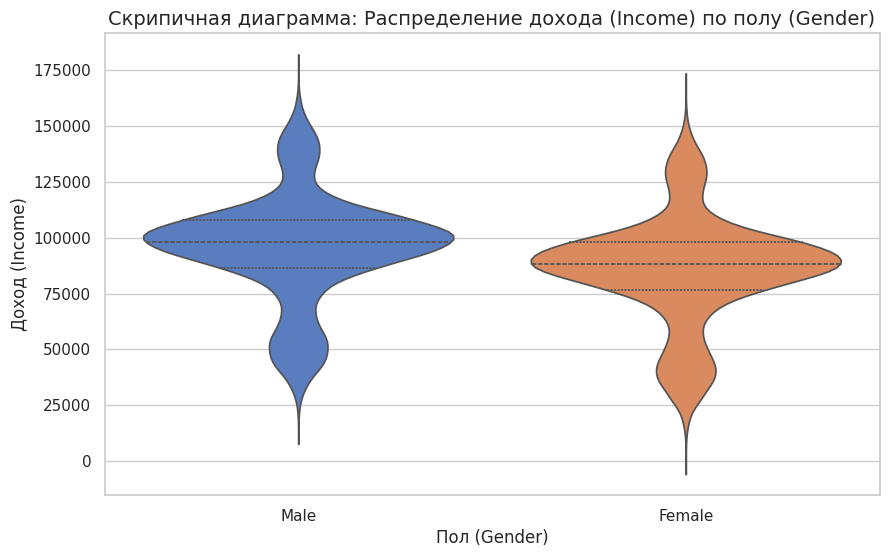

In [4]:
# Создаем полотно нужного размера
plt.figure(figsize=(10, 6))

# Строим Violin plot
sns.violinplot(
    x='Gender', 
    y='Income', 
    data=df, 
    palette='muted',
    inner='quartile' # Отображение квартилей внутри скрипок
)

# Добавляем заголовки и подписи осей
plt.title('Скрипичная диаграмма: Распределение дохода (Income) по полу (Gender)', fontsize=14)
plt.xlabel('Пол (Gender)', fontsize=12)
plt.ylabel('Доход (Income)', fontsize=12)

# Отрисовка графика
plt.show()